# Post-Hoc Flow Preconditioning Experiments E0-E4

Runs the expanded shared protocol for E0 quadratic residual sanity, E1 fixed decoder inverse problem, E2 scalar graph-geometry landscapes, E3 nonsmooth residual map, and E4 tiny MLP weight-space optimization. The notebook is cache-first and delegates the heavy protocol implementation to helper modules.

In [1]:
from __future__ import annotations

import json
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display

from post_train_research.loss_landscape_analysis.flow_preconditioning import ExperimentConfig, run_or_load
from post_train_research.loss_landscape_analysis.flow_preconditioning.reporting import geometry_summary, paired_deltas
from post_train_research.loss_landscape_analysis.flow_preconditioning.toy_mlp import MLPRegressionProblem, mlp_forward

plt.rcParams['figure.dpi'] = 130

cfg = ExperimentConfig(
    run_label='e0_e4_paperish',
    artifact_root='artifacts/loss_landscape_analysis/flow_preconditioning',
    cache_first=True,
    force_rerun=False,
    seeds=(0, 1, 2, 3, 4),
    k_tune=8,
    k_eval=32,
    budgets=(300, 1000),
    downstream_tuning_batch_size=288,
    downstream_eval_batch_size=288,
    parallel_contexts=3,
    e2_gamma_values=(0.3, 1.0, 3.0),
    e2_dims=(2, 4),
    e2_objectives=('rastrigin_abs', 'rosenbrock_abs'),
    e3_condition_numbers=(1.0, 1e2, 1e4),
    e4_rho_values=(0.0, 1e-3, 1e-2, 5e-2),
    e4_main_rho=1e-2,
)

tables = run_or_load(cfg)
figure_dir = tables.output_dir / 'figures'
print('output_dir:', tables.output_dir)
print('results:', tables.results.shape)
print('curves:', tables.curves.shape)
print('geometry:', tables.geometry.shape)
print('selected_lrs:', tables.selected_lrs.shape)
print('trajectories:', tables.trajectories.shape)
print('warped_grids:', tables.warped_grids.shape)


2026-06-08 14:18:40,280 | INFO | cache miss or force rerun output_dir=/home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish
2026-06-08 14:18:40,282 | INFO | run start output_dir=/home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish device=cuda:0 seeds=(0, 1, 2, 3, 4) budgets=(300, 1000)
2026-06-08 14:19:25,855 | INFO | planned contexts=105 parallel_contexts=5
2026-06-08 14:19:25,856 | INFO | parallel context execution enabled workers=5
2026-06-08 14:19:25,856 | INFO | context 1/105 queued [E0 task=quadratic_residual cond_A=1000.0 seed=0]
2026-06-08 14:19:25,857 | INFO | [E0 task=quadratic_residual cond_A=1000.0 seed=0] context start dim=16 flow_samples=912 heldout_samples=128 tune_starts=8 eval_starts=32
2026-06-08 14:19:25,858 | INFO | context 2/105 queued [E1 task=fixed_decoder_inverse decoder=fixed seed=0]
2026-06-08 14:19:25

## Tables

In [2]:
geom_summary = geometry_summary(tables.geometry)
delta_table = paired_deltas(tables.results)

display(Markdown('### Selected learning rates'))
display(tables.selected_lrs.sort_values(['experiment', 'task', 'condition_name', 'condition_value', 'seed', 'budget', 'method']).head(80))

display(Markdown('### Aggregate metrics'))
display(tables.aggregate.sort_values(['experiment', 'task', 'condition_name', 'condition_value', 'budget', 'optimizer', 'method']).head(120))

display(Markdown('### Geometry diagnostics'))
display(geom_summary.sort_values(['experiment', 'task', 'condition_name', 'condition_value', 'diagnostic', 'coordinate', 'seed']).head(120))

display(Markdown('### Paired AULC deltas'))
display(delta_table.groupby(['experiment', 'task', 'condition_name', 'condition_value', 'budget', 'optimizer', 'comparison'])['delta_aulc'].median().reset_index().head(120))


### Selected learning rates

,experiment,task,condition_name,condition_value,seed,budget,family,method,optimizer,selected_lr,median_tune_aulc
0,E0,quadratic_residual,cond_A,1000.0,0,300,direct,direct_adam,adam,0.0001,NaN
1,E0,quadratic_residual,cond_A,1000.0,0,300,direct,direct_sgd,sgd,0.0001,NaN
2,E0,quadratic_residual,cond_A,1000.0,0,300,random_flow,random_flow_adam,adam,0.0001,NaN
3,E0,quadratic_residual,cond_A,1000.0,0,300,random_flow,random_flow_sgd,sgd,0.0001,NaN
4,E0,quadratic_residual,cond_A,1000.0,0,300,trained_flow,trained_flow_adam,adam,0.0001,NaN
...,...,...,...,...,...,...,...,...,...,...,...
75,E1,fixed_decoder_inverse,decoder,fixed,1,300,random_flow,random_flow_sgd,sgd,0.1000,-1814.939425
76,E1,fixed_decoder_inverse,decoder,fixed,1,300,trained_flow,trained_flow_adam,adam,0.0100,-731.145655
77,E1,fixed_decoder_inverse,decoder,fixed,1,300,trained_flow,trained_flow_sgd,sgd,0.1000,-2501.956685
78,E1,fixed_decoder_inverse,decoder,fixed,1,1000,direct,direct_adam,adam,0.0100,-6129.387219


### Aggregate metrics

,experiment,task,condition_name,condition_value,numeric_condition,budget,method,optimizer,n,median_aulc,median_aulc_ci_low,median_aulc_ci_high,median_final_loss,median_best_seen_loss,median_final_test_loss,success_rate
0,E0,quadratic_residual,cond_A,1000.0,1000.0,300,direct_adam,adam,160,1236.235338,1221.953009,1255.214109,152519.156250,152519.156250,152519.156250,0.05625
2,E0,quadratic_residual,cond_A,1000.0,1000.0,300,random_flow_adam,adam,160,1237.062729,1216.577585,1253.777184,152519.007812,152519.007812,152519.007812,0.05625
4,E0,quadratic_residual,cond_A,1000.0,1000.0,300,trained_flow_adam,adam,160,1356.040237,1340.758276,1368.762207,179880.726562,179880.726562,179880.726562,0.03750
1,E0,quadratic_residual,cond_A,1000.0,1000.0,300,direct_sgd,sgd,160,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
3,E0,quadratic_residual,cond_A,1000.0,1000.0,300,random_flow_sgd,sgd,160,NaN,NaN,NaN,NaN,NaN,NaN,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,E2,rosenbrock_abs_d2,gamma,1.0,1.0,1000,random_flow_adam,adam,160,481.313933,336.379845,650.302604,3.520747,3.520747,3.520747,0.21875
118,E2,rosenbrock_abs_d2,gamma,1.0,1.0,1000,trained_flow_adam,adam,160,-103.145874,-392.090072,97.666129,2.823234,2.823234,2.823234,0.34375
115,E2,rosenbrock_abs_d2,gamma,1.0,1.0,1000,direct_sgd,sgd,160,NaN,-4074.933746,-3135.564323,2.401096,2.401096,2.401096,0.37500
117,E2,rosenbrock_abs_d2,gamma,1.0,1.0,1000,random_flow_sgd,sgd,160,NaN,-4074.933746,-3135.564323,2.401096,2.401096,2.401096,0.37500


### Geometry diagnostics

,experiment,task,condition_name,condition_value,diagnostic,coordinate,seed,numeric_condition,isometry_objective,median_condition_number,median_log_condition_number,trace_g_cv,median_flow_log_abs_det_jacobian,median_flow_condition_number,median_flow_displacement_norm
0,E0,quadratic_residual,cond_A,1000.0,coordinate_map,random_flow,0,1000.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0
1,E0,quadratic_residual,cond_A,1000.0,coordinate_map,random_flow,1,1000.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0
2,E0,quadratic_residual,cond_A,1000.0,coordinate_map,random_flow,2,1000.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0
3,E0,quadratic_residual,cond_A,1000.0,coordinate_map,random_flow,3,1000.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0
4,E0,quadratic_residual,cond_A,1000.0,coordinate_map,random_flow,4,1000.0,NaN,NaN,NaN,NaN,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,E2,rastrigin_abs_d2,gamma,3.0,pullback_metric,random_flow,0,3.0,2.913404,141.121098,4.949618,0.491944,NaN,NaN,NaN
116,E2,rastrigin_abs_d2,gamma,3.0,pullback_metric,random_flow,1,3.0,2.917449,136.247560,4.914473,0.493799,NaN,NaN,NaN
117,E2,rastrigin_abs_d2,gamma,3.0,pullback_metric,random_flow,2,3.0,2.908371,150.000817,5.010640,0.490261,NaN,NaN,NaN
118,E2,rastrigin_abs_d2,gamma,3.0,pullback_metric,random_flow,3,3.0,2.957695,129.805386,4.866036,0.504171,NaN,NaN,NaN


### Paired AULC deltas

,experiment,task,condition_name,condition_value,budget,optimizer,comparison,delta_aulc
0,E0,quadratic_residual,cond_A,1000.0,300,adam,trained_minus_direct,119.344185
1,E0,quadratic_residual,cond_A,1000.0,300,adam,trained_minus_random,119.845289
2,E0,quadratic_residual,cond_A,1000.0,300,sgd,trained_minus_direct,NaN
3,E0,quadratic_residual,cond_A,1000.0,300,sgd,trained_minus_random,NaN
4,E0,quadratic_residual,cond_A,1000.0,1000,adam,trained_minus_direct,397.962707
...,...,...,...,...,...,...,...,...
115,E3,relu_residual,cond_S,1.0,300,sgd,trained_minus_random,832.533594
116,E3,relu_residual,cond_S,1.0,1000,adam,trained_minus_direct,2460.630716
117,E3,relu_residual,cond_S,1.0,1000,adam,trained_minus_random,2459.403178
118,E3,relu_residual,cond_S,1.0,1000,sgd,trained_minus_direct,2096.744066


## Representative E0-E4 Plots

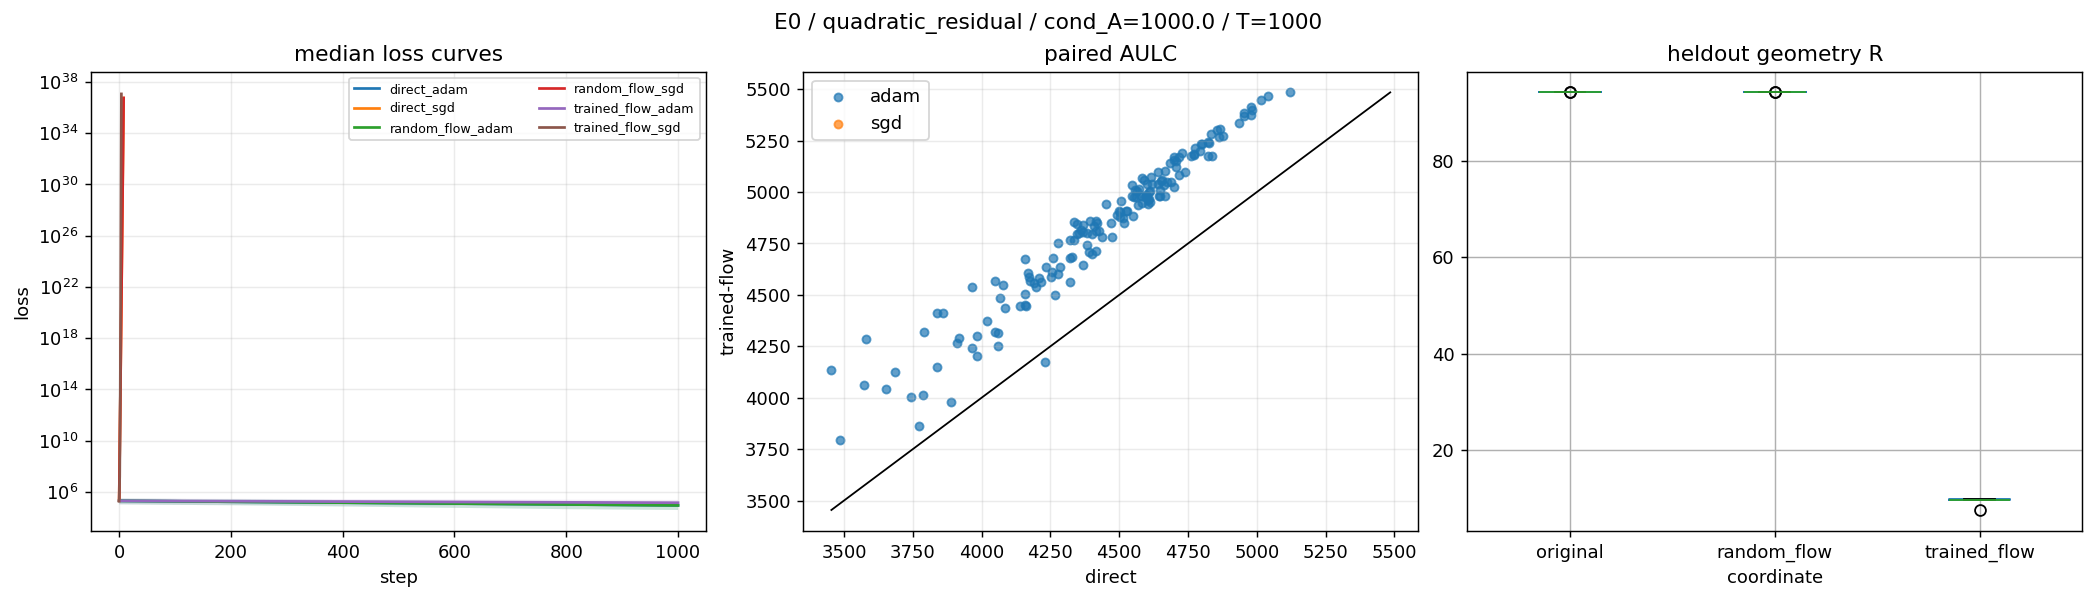

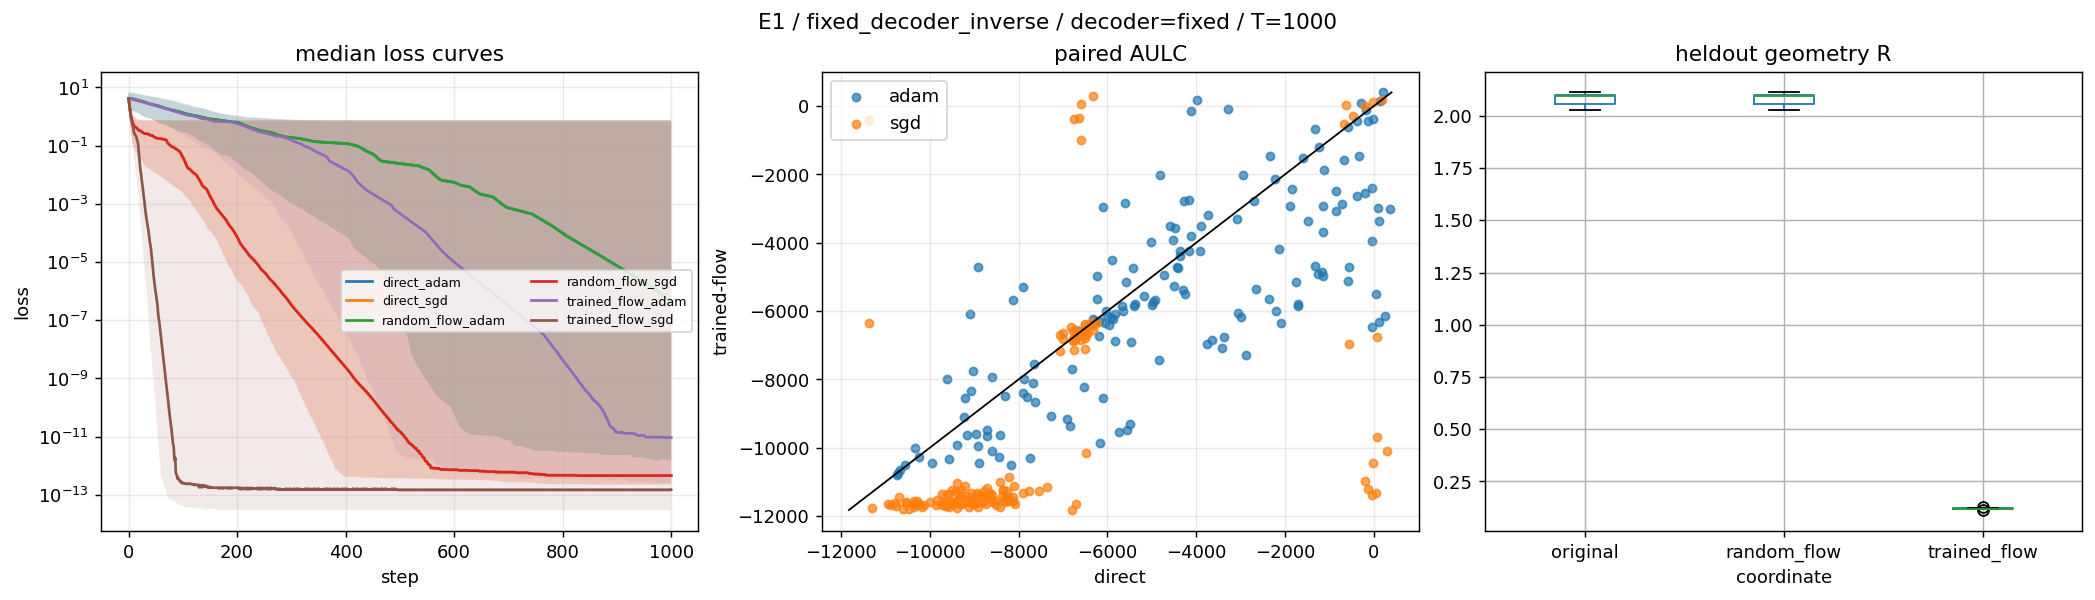

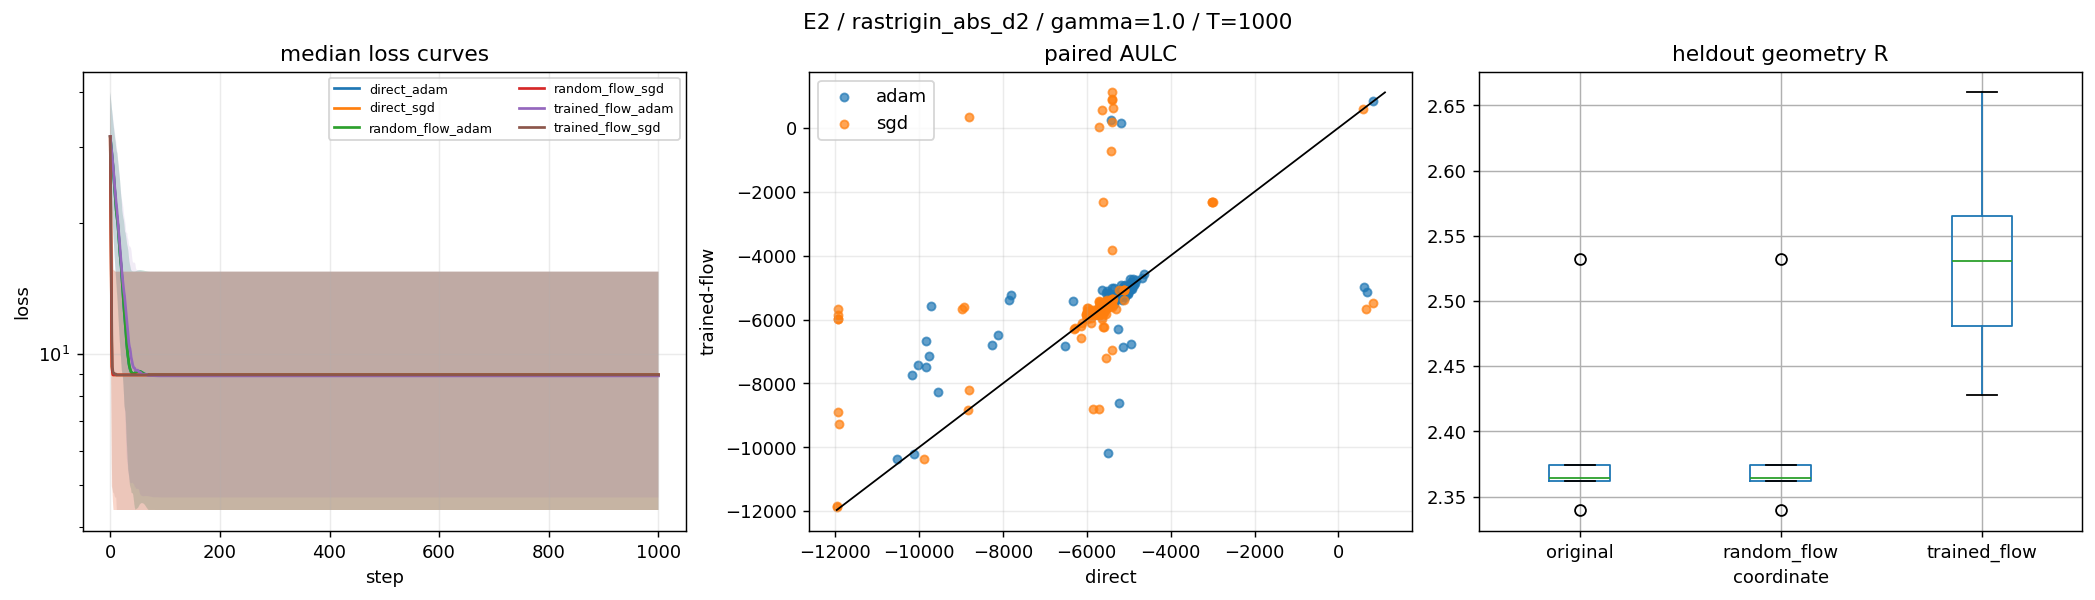

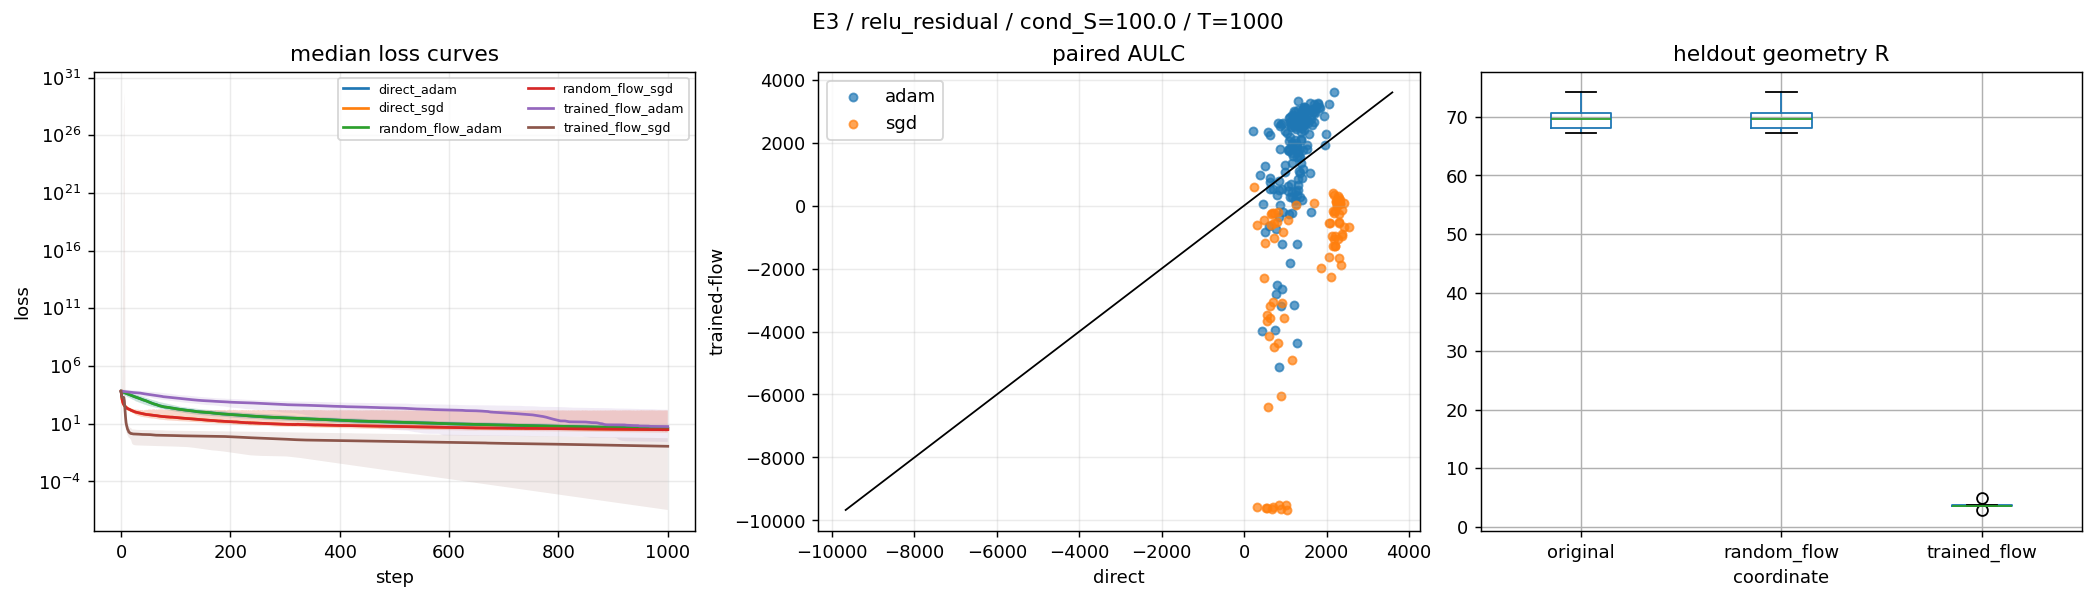

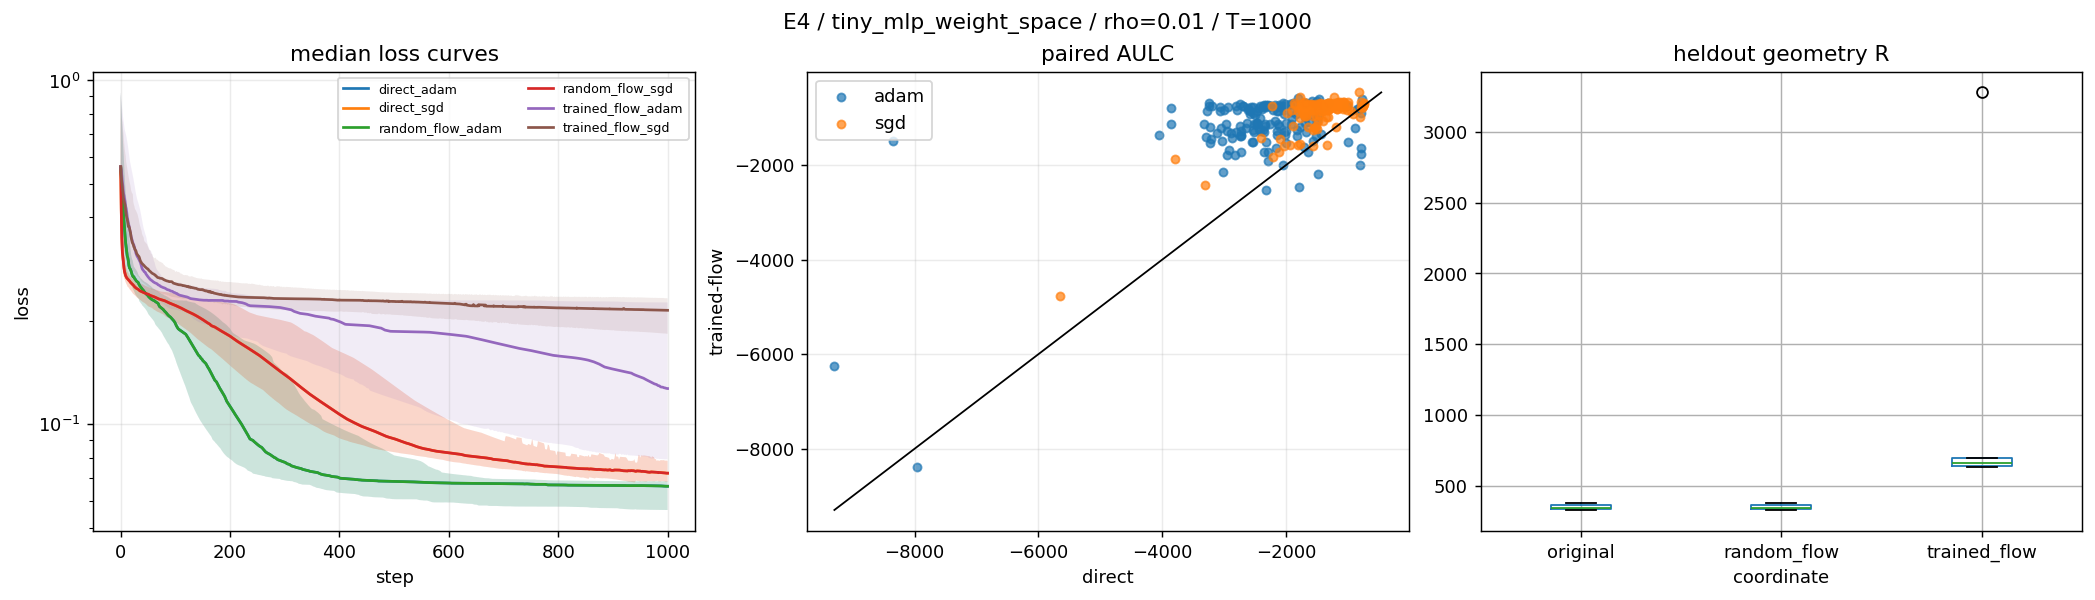

In [3]:
def condition_filter(frame: pd.DataFrame, experiment: str, task: str, condition_name: str, condition_value: str):
    return frame[
        (frame['experiment'] == experiment)
        & (frame['task'] == task)
        & (frame['condition_name'] == condition_name)
        & (frame['condition_value'].astype(str) == str(condition_value))
    ]

def plot_condition(experiment: str, task: str, condition_name: str, condition_value: str, *, budget: int | None = None):
    budget = int(max(cfg.budgets) if budget is None else budget)
    curves = condition_filter(tables.curves, experiment, task, condition_name, condition_value)
    curves = curves[(curves['split'] == 'eval') & (curves['budget'] == budget)]
    if curves.empty:
        print('no curves for', experiment, task, condition_name, condition_value)
        return
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    for method, frame in curves.groupby('method'):
        grouped = frame.groupby('step')['train_loss']
        median = grouped.median()
        q25 = grouped.quantile(0.25)
        q75 = grouped.quantile(0.75)
        axes[0].plot(median.index, median.values, label=method)
        axes[0].fill_between(median.index, q25.values, q75.values, alpha=0.12)
    axes[0].set_yscale('log')
    axes[0].set_title('median loss curves')
    axes[0].set_xlabel('step')
    axes[0].set_ylabel('loss')
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(fontsize=7, ncol=2)

    deltas = condition_filter(delta_table, experiment, task, condition_name, condition_value)
    scatter = deltas[(deltas['budget'] == budget) & (deltas['comparison'] == 'trained_minus_direct')]
    for optimizer, frame in scatter.groupby('optimizer'):
        axes[1].scatter(frame['right_aulc'], frame['left_aulc'], s=20, alpha=0.7, label=optimizer)
    if not scatter.empty:
        lo = float(np.nanmin([scatter['right_aulc'].min(), scatter['left_aulc'].min()]))
        hi = float(np.nanmax([scatter['right_aulc'].max(), scatter['left_aulc'].max()]))
        axes[1].plot([lo, hi], [lo, hi], color='black', linewidth=1)
    axes[1].set_title('paired AULC')
    axes[1].set_xlabel('direct')
    axes[1].set_ylabel('trained-flow')
    axes[1].grid(True, alpha=0.25)
    axes[1].legend()

    geom = condition_filter(geom_summary, experiment, task, condition_name, condition_value)
    geom = geom[geom['diagnostic'] == 'pullback_metric']
    if not geom.empty:
        geom.boxplot(column='isometry_objective', by='coordinate', ax=axes[2])
    axes[2].set_title('heldout geometry R')
    axes[2].set_xlabel('coordinate')
    fig.suptitle(f'{experiment} / {task} / {condition_name}={condition_value} / T={budget}')
    plt.show()

representatives = [
    ('E0', 'quadratic_residual', 'cond_A', '1000.0'),
    ('E1', 'fixed_decoder_inverse', 'decoder', 'fixed'),
    ('E2', 'rastrigin_abs_d2', 'gamma', '1.0'),
    ('E3', 'relu_residual', 'cond_S', '100.0'),
    ('E4', 'tiny_mlp_weight_space', 'rho', str(cfg.e4_main_rho)),
]
for args in representatives:
    plot_condition(*args)


## E1 Loss Curves

In [ ]:
e1_budget = int(max(cfg.budgets))
e1_curves = condition_filter(tables.curves, 'E1', 'fixed_decoder_inverse', 'decoder', 'fixed')
e1_curves = e1_curves[(e1_curves['split'] == 'eval') & (e1_curves['budget'] == e1_budget)]
if e1_curves.empty:
    print('no E1 eval curves for budget', e1_budget)
else:
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    for method, frame in e1_curves.groupby('method'):
        grouped = frame.groupby('step')['train_loss']
        median = grouped.median()
        q25 = grouped.quantile(0.25)
        q75 = grouped.quantile(0.75)
        ax.plot(median.index, median.values, label=method)
        ax.fill_between(median.index, q25.values, q75.values, alpha=0.10)
    ax.set_yscale('log')
    ax.set_xlabel('step')
    ax.set_ylabel('train loss')
    ax.set_title(f'E1 fixed decoder inverse loss / T={e1_budget}')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, ncol=2)
    e1_loss_path = figure_dir / 'e1_loss_curves.png'
    fig.savefig(e1_loss_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', e1_loss_path)


## Low-Dimensional Trajectories And Warped Grids

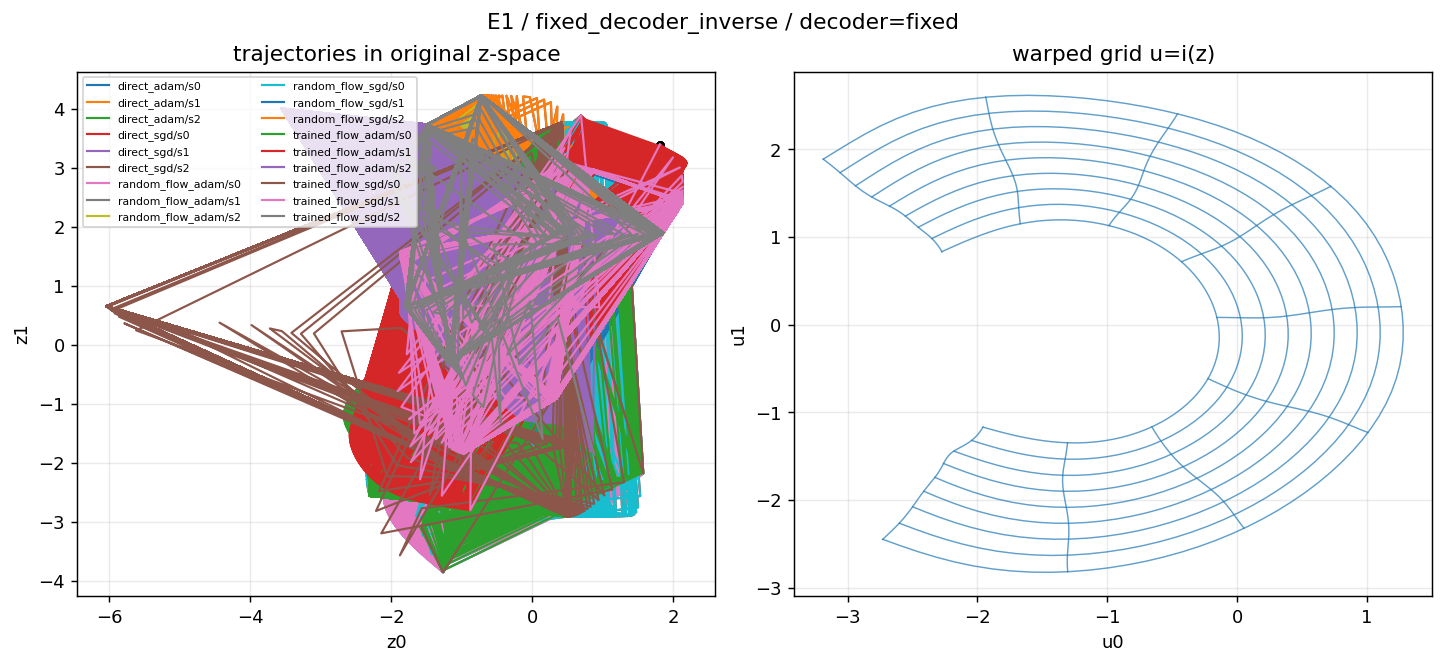

/home/coder/tmp/ipykernel_1191827/1447465530.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=6, ncol=2)


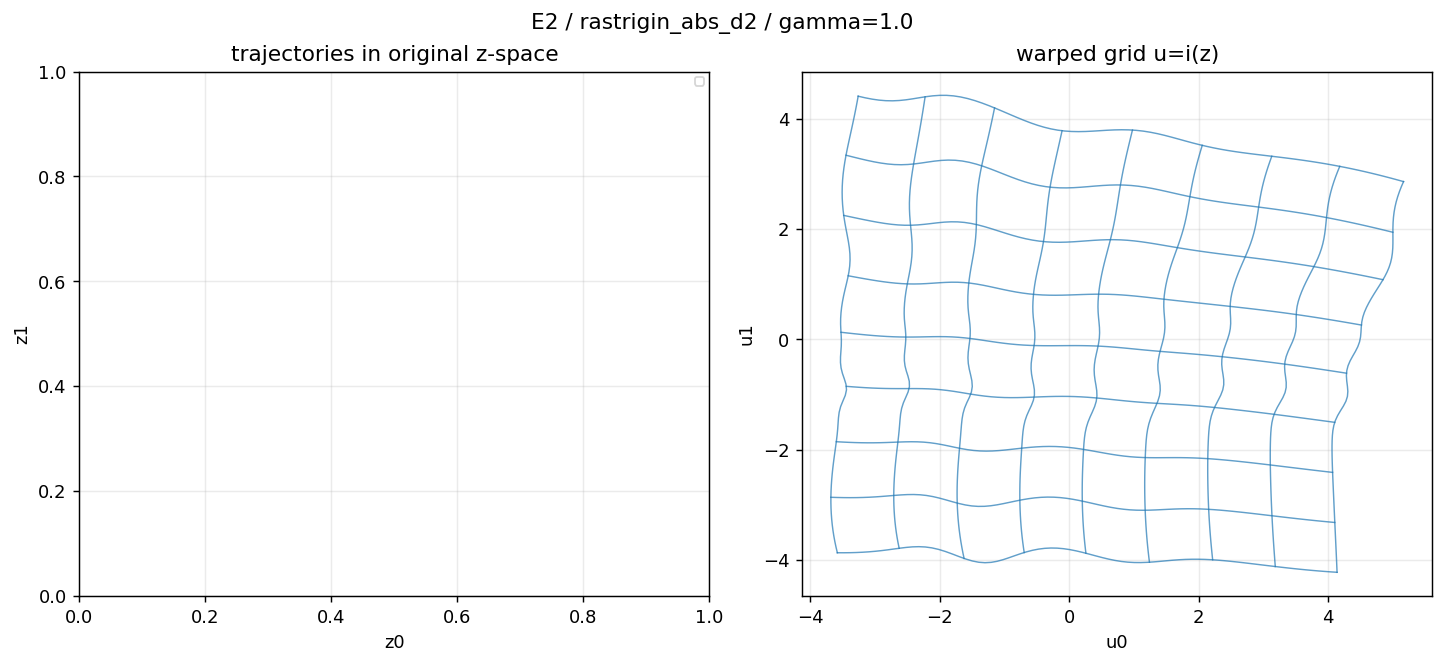

In [4]:
def plot_low_dim_visuals(experiment: str, task: str, condition_name: str, condition_value: str):
    traj = condition_filter(tables.trajectories, experiment, task, condition_name, condition_value)
    warp = condition_filter(tables.warped_grids, experiment, task, condition_name, condition_value)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
    if not traj.empty:
        for (method, start_index), frame in traj.groupby(['method', 'start_index']):
            points = np.array([json.loads(value) for value in frame.sort_values('step')['z_json']], dtype=float)
            if points.shape[1] >= 2:
                axes[0].plot(points[:, 0], points[:, 1], linewidth=1.2, label=f'{method}/s{start_index}')
                axes[0].scatter(points[0, 0], points[0, 1], s=14, color='black')
    axes[0].set_title('trajectories in original z-space')
    axes[0].set_xlabel('z0')
    axes[0].set_ylabel('z1')
    axes[0].grid(True, alpha=0.25)
    axes[0].legend(fontsize=6, ncol=2)

    warp = warp[warp['flow'] == 'trained_flow']
    if not warp.empty:
        seed = sorted(warp['seed'].unique())[0]
        warp = warp[warp['seed'] == seed]
        for (_axis, _line_index), line in warp.groupby(['axis', 'line_index']):
            line = line.sort_values('point_index')
            axes[1].plot(line['u0'], line['u1'], color='tab:blue', linewidth=0.8, alpha=0.7)
    axes[1].set_title('warped grid u=i(z)')
    axes[1].set_xlabel('u0')
    axes[1].set_ylabel('u1')
    axes[1].grid(True, alpha=0.25)
    fig.suptitle(f'{experiment} / {task} / {condition_name}={condition_value}')
    plt.show()

plot_low_dim_visuals('E1', 'fixed_decoder_inverse', 'decoder', 'fixed')
plot_low_dim_visuals('E2', 'rastrigin_abs_d2', 'gamma', '1.0')


## E4 Representative Predictions

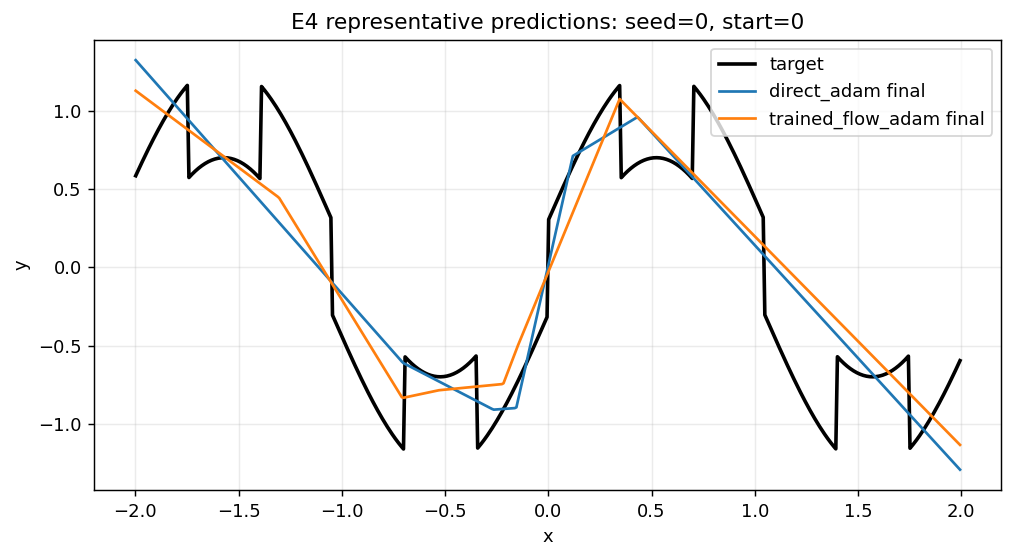

In [5]:
e4 = condition_filter(tables.results, 'E4', 'tiny_mlp_weight_space', 'rho', str(cfg.e4_main_rho))
e4 = e4[(e4['split'] == 'eval') & (~e4['candidate']) & (e4['budget'] == int(max(cfg.budgets)))]
pairs = e4[e4['method'].isin(['direct_adam', 'trained_flow_adam'])]
chosen = None
for key, frame in pairs.groupby(['seed', 'start_index']):
    if {'direct_adam', 'trained_flow_adam'}.issubset(set(frame['method'])):
        chosen = key
        break
if chosen is None:
    raise RuntimeError('No matched E4 direct/trained Adam pair found')
seed, start_index = chosen
plot_cfg = replace(cfg, device='cpu', dtype='float32')
problem = MLPRegressionProblem(plot_cfg, seed=int(seed), device=torch.device('cpu'), dtype=torch.float32)
x = problem.x_test.detach().cpu()
target = problem.y_test.detach().cpu()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x.numpy(), target.numpy(), color='black', linewidth=2, label='target')
for method, frame in pairs[(pairs['seed'] == seed) & (pairs['start_index'] == start_index)].groupby('method'):
    theta = torch.tensor(json.loads(frame.iloc[0]['final_theta_json']), dtype=torch.float32)
    pred = mlp_forward(theta, x).detach().cpu()
    ax.plot(x.numpy(), pred.numpy(), label=f'{method} final')
ax.set_title(f'E4 representative predictions: seed={seed}, start={start_index}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.25)
ax.legend()
fig.savefig(figure_dir / 'E4_representative_predictions.png', dpi=160, bbox_inches='tight')
plt.show()


## E4 Long NF Rerun

In [ ]:
run_e4_long_nf = False
e4_long_nf_steps = 10000
e4_long_rhos = tuple(cfg.e4_rho_values)

if run_e4_long_nf:
    e4_long_cfg = replace(
        cfg,
        run_label=f'{cfg.run_label}_e4_nf{e4_long_nf_steps}',
        experiments=('E4',),
        e4_flow_steps=e4_long_nf_steps,
        e4_rho_values=e4_long_rhos,
        cache_first=True,
        force_rerun=False,
        parallel_contexts=3,
    )
    e4_long_tables = run_or_load(e4_long_cfg)
    print('E4 long NF output_dir:', e4_long_tables.output_dir)
    display(e4_long_tables.aggregate.sort_values(['condition_value', 'budget', 'optimizer', 'method']).head(80))
else:
    print('Set run_e4_long_nf=True to recompute E4 only with longer NF training.')


## Saved Figures

In [6]:
print('figure_dir:', figure_dir)
for name, path in list(tables.figure_paths.items())[:20]:
    print(name, '->', path)


figure_dir: /home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish/figures
median_curves__E0__quadratic_residual__cond_A__1000.0 -> /home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish/figures/median_curves__E0__quadratic_residual__cond_A__1000.0.png
median_curves__E1__fixed_decoder_inverse__decoder__fixed -> /home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish/figures/median_curves__E1__fixed_decoder_inverse__decoder__fixed.png
median_curves__E2__rastrigin_abs_d2__gamma__0.3 -> /home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish/figures/median_curves__E2__rastrigin_abs_d2__gamma__0.3.png
median_curves__E2__rastrigin_abs_d2__gamma__1.0 -> /home/coder/project/post_train

## Automatic Interpretation

In [7]:
display(Markdown(tables.interpretation_markdown))
print('interpretation saved to:', tables.output_dir / 'interpretation.md')


## Automatic Interpretation

### E0
1. Held-out geometry improved: **yes** (median R original=94.21, trained=9.666).
2. Trained-flow AULC improved over direct: **no** (median delta=398; negative is better).
3. Improvement survived random-flow baseline: **no** (median trained-random delta=394.7).
4. Stronger optimizer: **Adam** (SGD delta=nan, Adam delta=398).
5. Conditions that mattered most: best=('quadratic_residual', 'cond_A', '1000.0') (398), worst=('quadratic_residual', 'cond_A', '1000.0') (398).
6. Mechanism verdict: not enough paired evidence to rule out LR/step-size or random-coordinate artifacts.

### E1
1. Held-out geometry improved: **yes** (median R original=2.097, trained=0.1189).
2. Trained-flow AULC improved over direct: **yes** (median delta=-1300; negative is better).
3. Improvement survived random-flow baseline: **yes** (median trained-random delta=-1300).
4. Stronger optimizer: **SGD** (SGD delta=-2071, Adam delta=-463.3).
5. Conditions that mattered most: best=('fixed_decoder_inverse', 'decoder', 'fixed') (-1300), worst=('fixed_decoder_inverse', 'decoder', 'fixed') (-1300).
6. Mechanism verdict: consistent with learned nonlinear preconditioning.

### E2
1. Held-out geometry improved: **yes** (median R original=4.164, trained=0.5475).
2. Trained-flow AULC improved over direct: **yes** (median delta=-22.58; negative is better).
3. Improvement survived random-flow baseline: **yes** (median trained-random delta=-22.47).
4. Stronger optimizer: **Adam** (SGD delta=42.26, Adam delta=-149.1).
5. Conditions that mattered most: best=('rosenbrock_abs_d4', 'gamma', '3.0') (-613.1), worst=('rastrigin_abs_d4', 'gamma', '1.0') (119.9).
6. Mechanism verdict: consistent with learned nonlinear preconditioning.

### E3
1. Held-out geometry improved: **yes** (median R original=69.59, trained=3.708).
2. Trained-flow AULC improved over direct: **no** (median delta=910.5; negative is better).
3. Improvement survived random-flow baseline: **no** (median trained-random delta=910.5).
4. Stronger optimizer: **Adam** (SGD delta=1683, Adam delta=603.4).
5. Conditions that mattered most: best=('relu_residual', 'cond_S', '100.0') (-330.9), worst=('relu_residual', 'cond_S', '1.0') (2227).
6. Mechanism verdict: not enough paired evidence to rule out LR/step-size or random-coordinate artifacts.

### E4
1. Held-out geometry improved: **no** (median R original=345.8, trained=739.6).
2. Trained-flow AULC improved over direct: **no** (median delta=753.9; negative is better).
3. Improvement survived random-flow baseline: **no** (median trained-random delta=753.9).
4. Stronger optimizer: **SGD** (SGD delta=618.2, Adam delta=1117).
5. Conditions that mattered most: best=('tiny_mlp_weight_space', 'rho', '0.0') (721.1), worst=('tiny_mlp_weight_space', 'rho', '0.01') (772.7).
6. Mechanism verdict: not enough paired evidence to rule out LR/step-size or random-coordinate artifacts.


interpretation saved to: /home/coder/project/post_train_research/loss_landscape_analysis/artifacts/loss_landscape_analysis/flow_preconditioning/e0_e4_paperish/interpretation.md
